<div style="text-align:center; padding:20px 0">
<img src="https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/media/logo_dataprojectlab.png" width="200"/>
</div>


# AfriCare Support Analytics — Masterclass Pratique
## ✅ VERSION CORRIGÉE

---

> **Comment lire ce notebook :**
> - Les blocs `🎓 MÉTHODE` expliquent le **pourquoi** de chaque technique
> - Les blocs `💡 INTERPRÉTATION` lisent les résultats avec les chiffres réels
> - Les blocs `🏢 ACTION MÉTIER` traduisent le chiffre en décision opérationnelle pour M. Kouame
> - Les blocs SQL utilisent la syntaxe `%%sql` (JupySQL) — le résultat est directement un DataFrame

| | |
|---|---|
| **Projet** | Customer Support Analytics — AfriCare Services |
| **Durée masterclass** | 3 heures |
| **Stack** | Python · DuckDB (JupySQL) · scikit-learn · Power BI |
| **Niveau** | Avancé |

### Plan de la masterclass

| Partie | Sujet | Durée |
|---|---|---|
| **0** | Setup & contexte métier | 10 min |
| **1** | Chargement & audit des données | 20 min |
| **2** | Nettoyage & feature engineering | 30 min |
| **3** | SQL Analytics — KPIs & performance | 50 min |
| **4** | Machine Learning — détection de risque | 45 min |
| **5** | Power BI — architecture & DAX | 25 min |


---
## ⚙️ Partie 0 — Setup `[10 min]`

In [31]:
# Installation des librairies nécessaires
!pip install duckdb jupysql --quiet



[notice] A new release of pip is available: 24.1 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [32]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
import duckdb
import os

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9F9F8',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

COLORS = {
    'primary':   '#534AB7',
    'secondary': '#1D9E75',
    'warning':   '#EF9F27',
    'danger':    '#E24B4A',
    'neutral':   '#888780',
}

print('✅ Imports OK')


✅ Imports OK


### Chargement des données

> **Option A — Google Drive :** si le formateur a partagé le dossier, monte ton Drive.
> **Option B — Fallback GitHub :** si Drive non disponible, les CSV sont chargés automatiquement depuis GitHub.


In [33]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/DataProjectLab/projects/customer_support/dataset/'
else:
    DATA_PATH = './dataset/'

USE_GITHUB = not os.path.exists(DATA_PATH)
BASE_URL   = 'https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/projets/customer_support/data/'

def load_csv(name, **kwargs):
    path = DATA_PATH + name if not USE_GITHUB else BASE_URL + name
    return pd.read_csv(path, **kwargs)

print(f'📁 Source : {"GitHub" if USE_GITHUB else DATA_PATH}')


📁 Source : GitHub


---
## 📦 Partie 1 — Chargement & Audit des données `[20 min]`

### Le dictionnaire des données

> 🎓 **Avant de toucher au code, lire toujours le dictionnaire en entier.**
> C'est l'étape la plus sous-estimée par les analystes juniors.

| Table | Lignes | Description |
|---|---|---|
| `tickets.csv` | 15 287 | Table principale — un ticket = une ligne |
| `agents.csv` | 12 | L'équipe support |
| `categories.csv` | variable | Catégories de problèmes avec SLA associé |
| `interactions.csv` | variable | Échanges email/chat par ticket |
| `sla_alerts.csv` | variable | Alertes SLA déclenchées |

**Colonnes clés de `tickets.csv` :**

| Colonne | Description |
|---|---|
| `ticket_id` | Identifiant unique TKT000001 |
| `sla_breach` | ⭐ **Variable cible** : 1 si SLA dépassé, 0 sinon |
| `ratio_sla` | `resolution_heures / sla_heures` — ratio > 1 = breach |
| `first_response_heures` | Délai avant première réponse |
| `resolution_heures` | Durée totale de résolution |
| `csat` | Note satisfaction 1-5 (NULL si pas de retour) |
| `in_backlog` | 1 si ticket en backlog |
| `reopened` | 1 si ticket rouvert |

> 🎓 **Point clé :** `sla_breach` et `ratio_sla` sont liés logiquement.
> Si `ratio_sla > 1` alors `sla_breach` **doit** valoir 1. Vérifier cette cohérence
> est la première vérification à faire dans l'audit.


In [34]:
# Chargement des 5 tables
BASE_URL = "https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/main/projets/customer_support_analytics/data/"


agents     = pd.read_csv(BASE_URL + "agents.csv")
categories = pd.read_csv(BASE_URL + "categories.csv")
tickets    = pd.read_csv(BASE_URL + "tickets.csv", parse_dates=['created_at'])
interactions = pd.read_csv(BASE_URL + "interactions.csv", parse_dates=['timestamp'])
sla_alerts = pd.read_csv(BASE_URL + "sla_alerts.csv", parse_dates=['alert_timestamp'])

# Vérification immédiate des dimensions
print(f"{'Table':<15} {'Lignes':>8} {'Colonnes':>10}")
print("-" * 36)
for name, df in [('tickets', tickets), ('agents', agents), ('categories', categories),
                  ('interactions', interactions), ('sla_alerts', sla_alerts)]:
    print(f"{name:<15} {len(df):>8,} {len(df.columns):>10}")


Table             Lignes   Colonnes
------------------------------------
tickets           15,287         19
agents                12          7
categories            10          7
interactions      15,779          6
sla_alerts         2,000          5


### Audit qualité rapide

> 🎓 **L'audit avant le nettoyage.** On cherche : nulls, doublons, types incorrects,
> incohérences métier. En 5 minutes, on sait ce qu'il faut corriger.


In [35]:
# 1. Nulls sur les colonnes critiques
cols_critiques = ['sla_breach', 'ratio_sla', 'first_response_heures',
                   'resolution_heures', 'csat', 'agent_id', 'category_id']
print('Nulls sur colonnes critiques :')
for col in cols_critiques:
    if col in tickets.columns:
        n = tickets[col].isnull().sum()
        pct = n / len(tickets) * 100
        flag = '⚠️ ' if n > 0 else '✅'
        print(f'  {flag} {col:<30} : {n:>5} nulls ({pct:.1f}%)')

print()
# 2. Doublons
n_dup = tickets['ticket_id'].duplicated().sum()
print(f'Doublons ticket_id     : {n_dup} {"⚠️" if n_dup > 0 else "✅"}')

# 3. Délais négatifs (anomalie technique)
n_neg_first = (tickets['first_response_heures'] < 0).sum()
n_neg_resol = (tickets['resolution_heures'] < 0).sum()
print(f'Délais négatifs first_response  : {n_neg_first} {"⚠️" if n_neg_first > 0 else "✅"}')
print(f'Délais négatifs resolution       : {n_neg_resol} {"⚠️" if n_neg_resol > 0 else "✅"}')

# 4. Incohérence métier sla_breach / ratio_sla
incoherences = tickets[
    (tickets['ratio_sla'] > 1) & (tickets['sla_breach'] == 0) |
    (tickets['ratio_sla'] <= 1) & (tickets['sla_breach'] == 1)
]
print(f'Incohérences sla_breach/ratio_sla: {len(incoherences)} {"⚠️" if len(incoherences) > 0 else "✅"}')

# 5. Distribution variable cible
taux_breach = tickets['sla_breach'].mean() * 100
print(f'\nTaux SLA breach global  : {taux_breach:.1f}% — objectif secteur : < 10%')
print(f'Taux in_backlog         : {tickets["in_backlog"].mean()*100:.1f}%')
print(f'Taux reopened           : {tickets["reopened"].mean()*100:.1f}%')


Nulls sur colonnes critiques :
  ✅ sla_breach                     :     0 nulls (0.0%)
  ✅ ratio_sla                      :     0 nulls (0.0%)
  ✅ first_response_heures          :     0 nulls (0.0%)
  ✅ resolution_heures              :     0 nulls (0.0%)
  ⚠️  csat                           :  6742 nulls (44.1%)
  ✅ agent_id                       :     0 nulls (0.0%)
  ✅ category_id                    :     0 nulls (0.0%)

Doublons ticket_id     : 0 ✅
Délais négatifs first_response  : 0 ✅
Délais négatifs resolution       : 0 ✅
Incohérences sla_breach/ratio_sla: 2 ⚠️

Taux SLA breach global  : 47.3% — objectif secteur : < 10%
Taux in_backlog         : 7.4%
Taux reopened           : 7.7%


### 🏢 ACTION MÉTIER — Ce qu'on remonte à M. Kouame après l'audit

**La conversation d'ouverture :**

> *"Monsieur Kouame, avant de vous présenter les analyses, un point important :*
> *votre CRM affiche un taux SLA breach — mais nous avons détecté des incohérences*
> *entre le flag `sla_breach` et le calcul réel depuis les heures de résolution.*
> *Concrètement, des tickets qui ont réellement dépassé leur SLA n'étaient pas flaggés comme tels.*
> *Le taux réel corrigé est plus élevé que celui affiché dans vos rapports habituels."*

**Pourquoi c'est important en support client :**
- Les SLA sont souvent des **engagements contractuels avec pénalités financières**. Un SLA breach non détecté = une pénalité évitée par erreur, risque de litige si le client s'en aperçoit.
- Les reportings mensuels que M. Kouame envoie à sa direction sont basés sur ces flags. Il présente involontairement des chiffres sous-estimés.
- L'équipe de nuit ou le bureau étranger peut être responsable des incohérences (mise à jour asynchrone du CRM).

**Recommandations opérationnelles immédiates :**
1. **Audit CRM mensuel** : faire tourner cette vérification tous les mois pour détecter les régressions de synchronisation
2. **Communication équipe** : informer l'équipe support que le taux réel est plus élevé — ce n'est pas pour les pointer du doigt mais pour calibrer les attentes
3. **Bug CRM à remonter à l'IT** : le flag `sla_breach` devrait être recalculé en temps réel, pas en batch nocturne
4. **Dashboard Power BI = source de vérité** : dans la Partie 5, le dashboard affichera le taux réel corrigé — il faudra communiquer ce changement de référence aux utilisateurs


---
## 🧹 Partie 2 — Nettoyage & Feature Engineering `[30 min]`

> 🎓 **3 règles fondamentales de ce notebook :**
> 1. **Toujours justifier chaque décision** de nettoyage — médiane vs moyenne, left join vs inner join
> 2. **Distinguer anomalie technique et anomalie métier** — délai négatif = bug vs CSAT null = non applicable
> 3. **Définir la variable cible AVANT le feature engineering** pour éviter le data leakage


In [36]:
# ── Opération 1 : Suppression doublons clé primaire ────────────────────────
n_avant = len(tickets)
tickets = tickets.drop_duplicates(subset='ticket_id', keep='first').reset_index(drop=True)
print(f'Doublons supprimés : {n_avant - len(tickets)} lignes')

# ── Opération 2 : Imputation médiane sur délais négatifs ───────────────────
# Médiane (pas moyenne) car la distribution des délais est asymétrique (long tail)
for col in ['first_response_heures', 'resolution_heures']:
    mask_neg = tickets[col] < 0
    if mask_neg.sum() > 0:
        mediane = tickets.loc[tickets[col] >= 0, col].median()
        tickets.loc[mask_neg, col] = mediane
        print(f'Imputation médiane ({mediane:.1f}h) sur {mask_neg.sum()} délais négatifs — {col}')

# ── Opération 3 : Correction incohérences sla_breach / ratio_sla ──────────
# La source de vérité : ratio_sla (calculé depuis les heures réelles)
mask_inco = (
    ((tickets['ratio_sla'] > 1) & (tickets['sla_breach'] == 0)) |
    ((tickets['ratio_sla'] <= 1) & (tickets['sla_breach'] == 1))
)
tickets.loc[mask_inco, 'sla_breach'] = (tickets.loc[mask_inco, 'ratio_sla'] > 1).astype(int)
print(f'Incohérences sla_breach corrigées : {mask_inco.sum()}')
print('✅ Nettoyage terminé')


Doublons supprimés : 0 lignes
Incohérences sla_breach corrigées : 2
✅ Nettoyage terminé


### 🏢 ACTION MÉTIER — L'impact opérationnel du nettoyage

**Les 3 corrections qu'on vient d'appliquer ont des implications métier concrètes :**

**1 — Les doublons supprimés**
Un ticket qui apparaît deux fois dans le CRM peut signifier :
- Un agent qui a créé manuellement un ticket déjà créé par le système (Email → ticket auto + saisie manuelle)
- Une synchronisation qui a dédoublonné les entrées depuis 2 sources (Zendesk + Freshdesk après une migration)
- Un client qui a ouvert le même ticket par deux canaux (Chat puis Email) → à tracer en amont pour éviter la frustration du client

**Action pour M. Kouame :** si le nombre de doublons est significatif (> 1%), c'est le signe d'un problème de process à creuser avec l'équipe CRM.

**2 — Les délais négatifs**
Ces valeurs impossibles (`resolution_heures < 0`) viennent d'un bug de timestamp côté CRM.
**Le danger métier :** si ces valeurs étaient passées dans les rapports, elles auraient *diminué* artificiellement la résolution moyenne — tromperie involontaire.

**Action pour M. Kouame :** demander à l'IT de vérifier le fuseau horaire du serveur CRM. Les délais négatifs apparaissent souvent quand un ticket est créé dans un bureau (ex: Dakar, UTC+0) et résolu dans un autre (ex: Abidjan, UTC+0, mais avec un serveur mal configuré).

**3 — La correction des incohérences `sla_breach`**
**Cas concret :** si on a corrigé N tickets qui étaient réellement en breach mais non flaggés :
- Ces N clients pensent peut-être que leur ticket a été traité dans les délais
- Les agents qui les ont traités n'ont pas été alertés de la situation de breach
- Le reporting de performance de ces agents est faussé (à la hausse)

**Action pour M. Kouame :** communiquer à l'équipe que le taux de breach réel est plus élevé. C'est un travail délicat — il faut présenter ça comme une amélioration de la mesure, pas comme un reproche aux équipes.


### Fusion des tables

> 🎓 **Left join, pas inner join.**
> Inner join supprimerait les tickets sans agent ou catégorie connus.
> On veut les analyser — ils peuvent révéler un problème d'affectation.


In [37]:
# Fusion tickets + agents + catégories
df = (tickets
      .merge(agents[['agent_id', 'nom', 'tier', 'bureau',
                       'csat_moyen', 'taux_resolution_pct']],
             on='agent_id', how='left')
      .merge(categories[['category_id', 'nom', 'domaine',
                           'sla_heures', 'priorite_defaut']],
             on='category_id', how='left',
             suffixes=('', '_cat'))
)
print(f'Table fusionnée : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')


Table fusionnée : 15,287 lignes × 28 colonnes


### Feature Engineering

> 🎓 **L'ordre est impératif :** nettoyage → variable cible → features.
> Si une feature encode indirectement la cible (leakage), le modèle triche.


In [38]:
# ── Étape 1 : Variable cible ML ────────────────────────────────────────────
# ticket_at_risk = 1 si SLA dépassé OU en backlog OU escaladé OU rouvert
# On capture TOUTES les formes de risque, pas seulement le SLA
df['ticket_at_risk'] = (
    (df['sla_breach'] == 1) |
    (df['in_backlog'] == 1) |
    (df['statut'] == 'Escaladé') |
    (df['reopened'] == 1)
).astype(int)

print(f'ticket_at_risk = 1 : {df["ticket_at_risk"].sum():,} ({df["ticket_at_risk"].mean()*100:.1f}%)')
print(f'ticket_at_risk = 0 : {(df["ticket_at_risk"]==0).sum():,} ({(1-df["ticket_at_risk"].mean())*100:.1f}%)')

# ── Étape 2 : Features temporelles ──────────────────────────────────────────
df['heure_creation']  = df['created_at'].dt.hour
df['jour_semaine']    = df['created_at'].dt.dayofweek   # 0=Lun, 6=Dim
df['mois']            = df['created_at'].dt.month
df['est_weekend']     = (df['jour_semaine'] >= 5).astype(int)
df['est_heure_creuse']= df['heure_creation'].apply(
    lambda h: 1 if (h < 8 or h >= 20) else 0
)

# ── Étape 3 : Flags business ─────────────────────────────────────────────────
df['is_reponse_rapide']  = (df['first_response_heures'] <= 2).astype(int)   # < 2h
df['is_resolution_lente']= (df['resolution_heures'] > df['sla_heures']*0.8).astype(int)
df['is_priorite_haute']  = (df['priorite'] <= 2).astype(int)

print('\nFeatures créées :', ['heure_creation','jour_semaine','mois','est_weekend',
                                'est_heure_creuse','is_reponse_rapide',
                                'is_resolution_lente','is_priorite_haute'])


ticket_at_risk = 1 : 8,778 (57.4%)
ticket_at_risk = 0 : 6,509 (42.6%)

Features créées : ['heure_creation', 'jour_semaine', 'mois', 'est_weekend', 'est_heure_creuse', 'is_reponse_rapide', 'is_resolution_lente', 'is_priorite_haute']


### 🏢 ACTION MÉTIER — Pourquoi `ticket_at_risk` est plus pertinent que `sla_breach`

En support client, le risque ne se limite pas au SLA. Un client peut être satisfait
d'un SLA respecté techniquement mais insatisfait du service pour d'autres raisons :

| Situation | SLA | Mais... | Résultat pour le client |
|---|---|---|---|
| Ticket résolu en 3h sur SLA 24h | ✅ | Rouvert 2 jours après | Client frustré : problème non résolu |
| Ticket traité en 12h sur SLA 48h | ✅ | Escaladé 3 fois | Client excédé de répéter son problème |
| Ticket résolu rapidement | ✅ | Laissé en backlog 5 jours avant d'être pris | Client abandonné |

**`ticket_at_risk` = sla_breach OR in_backlog OR escaladé OR reopened** capture ces 4 formes de mauvaise expérience.

**L'impact business :**
Un ticket rouvert a typiquement **3× plus de chances de générer un churn** qu'un ticket résolu du premier coup.
Un ticket escaladé signifie que le client a dû **répéter son problème plusieurs fois** — l'un des irritants #1 identifiés par les études de satisfaction client.

**Action pour M. Kouame :**
Dans les reportings, ne plus suivre uniquement `sla_breach` mais `ticket_at_risk` comme KPI principal.
Le SLA devient un sous-KPI, avec trois autres indicateurs de même importance.


In [39]:
# Export du dataset nettoyé
df.to_csv('support_clean_analytics.csv', index=False)
print(f'✅ support_clean_analytics.csv exporté : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'\nRésumé :')
print(f'  Période      : {df["created_at"].min().date()} → {df["created_at"].max().date()}')
print(f'  Agents       : {df["agent_id"].nunique()}')
print(f'  Catégories   : {df["category_id"].nunique()}')
print(f'  Pays couverts: {df["pays"].nunique()}')


✅ support_clean_analytics.csv exporté : 15,287 lignes × 35 colonnes

Résumé :
  Période      : 2022-01-01 → 2024-06-30
  Agents       : 12
  Catégories   : 10
  Pays couverts: 8


---
## 🔎 Partie 3 — SQL Analytics : KPIs & Performance `[50 min]`

> 🎓 **Pourquoi DuckDB ?**
> DuckDB est portable — aucune installation serveur. Il lit les CSV directement avec
> `read_csv_auto` et supporte une syntaxe proche de PostgreSQL et SQL Server.
> Les requêtes de ce notebook fonctionnent dans SQL Server avec des ajustements mineurs.

**Patterns SQL à maîtriser dans cette partie :**
- `AVG(CASE WHEN cond THEN 1.0 ELSE 0.0 END)` — calcul de taux
- `RANK() OVER (ORDER BY ...)` — classement des agents
- `LAG(col) OVER (ORDER BY ...)` — comparaison période précédente
- `WITH ... AS (CTE)` — requête en deux étapes lisibles
- `CASE WHEN` dans `GROUP BY` — binning (tranches de délai)


In [40]:
# Connexion DuckDB et chargement des tables
import duckdb
con = duckdb.connect()


con.execute(f"""
    CREATE OR REPLACE  TABLE tickets      AS SELECT * FROM read_csv_auto('{BASE_URL}tickets.csv');
    CREATE OR REPLACE  TABLE agents       AS SELECT * FROM read_csv_auto('{BASE_URL}agents.csv');
    CREATE OR REPLACE  TABLE categories   AS SELECT * FROM read_csv_auto('{BASE_URL}categories.csv');
    CREATE OR REPLACE  TABLE interactions AS SELECT * FROM read_csv_auto('{BASE_URL}interactions.csv');
    CREATE OR REPLACE  TABLE sla_alerts   AS SELECT * FROM read_csv_auto('{BASE_URL}sla_alerts.csv');
""")


n = con.execute('SELECT COUNT(*) FROM tickets').fetchone()[0]
print(f'✅ {n:,} tickets chargés dans DuckDB')

# ── Activation de JupySQL — on peut maintenant écrire %%sql dans les cellules ──
%load_ext sql
%sql con --alias duckdb
%config SqlMagic.autopandas = True     # Le résultat du SQL est directement un DataFrame
%config SqlMagic.feedback = False      # Pas de messages parasites
print('%%sql prêt ✅')


✅ 15,287 tickets chargés dans DuckDB
%%sql prêt ✅


### 3.1 — KPIs globaux opérationnels

### 🎓 MÉTHODE — Pattern SQL universel pour calculer un taux

```sql
AVG(CASE WHEN sla_breach=1 THEN 1.0 ELSE 0.0 END) * 100
```

**Décortication du pattern :**
- `CASE WHEN condition THEN 1.0 ELSE 0.0` transforme chaque ligne en 0 ou 1 selon la condition
- `AVG(...)` calcule la moyenne des 0 et des 1 → proportion (entre 0 et 1)
- `* 100` convertit en pourcentage

**Pourquoi `1.0` et non `1` ?** En SQL, la division entière donnerait 0 pour tout taux < 100%.
Le `.0` force le calcul en flottant. Ce bug est l'une des erreurs SQL les plus fréquentes.

**Pourquoi calculer tous les KPIs dans UNE seule requête ?** Les dashboards Power BI rafraîchissent souvent.
Une seule requête = une seule lecture de la table = performance optimale.


In [41]:
%%sql df_kpi <<
SELECT
    COUNT(*)                                                              AS total_tickets,
    ROUND(AVG(CASE WHEN sla_breach=1       THEN 1.0 ELSE 0.0 END)*100, 1) AS taux_sla_breach_pct,
    ROUND(AVG(CASE WHEN statut='Résolu'    THEN 1.0 ELSE 0.0 END)*100, 1) AS taux_resolution_pct,
    ROUND(AVG(first_response_heures), 1)                                   AS moy_first_response_h,
    ROUND(AVG(resolution_heures), 1)                                       AS moy_resolution_h,
    ROUND(AVG(CASE WHEN csat IS NOT NULL THEN csat END), 2)                AS csat_moyen,
    ROUND(AVG(CASE WHEN in_backlog=1       THEN 1.0 ELSE 0.0 END)*100, 1) AS taux_backlog_pct,
    ROUND(AVG(CASE WHEN statut='Escaladé'  THEN 1.0 ELSE 0.0 END)*100, 1) AS taux_escalade_pct
FROM tickets


In [42]:
# Affichage des KPIs
print('═══════════════════════════════════════════════════')
print('  KPIs GLOBAUX — AfriCare Support')
print('═══════════════════════════════════════════════════')
for col, val in df_kpi.iloc[0].items():
    context = ''
    if col == 'taux_sla_breach_pct': context = '← objectif < 10%'
    if col == 'csat_moyen':           context = '← 4.5+ excellent · 3.5-4.5 correct · <3.5 critique'
    print(f'  {col:<28} : {str(val):>8}  {context}')


═══════════════════════════════════════════════════
  KPIs GLOBAUX — AfriCare Support
═══════════════════════════════════════════════════
  total_tickets                :  15287.0  
  taux_sla_breach_pct          :     47.3  ← objectif < 10%
  taux_resolution_pct          :     52.8  
  moy_first_response_h         :     36.8  
  moy_resolution_h             :    245.7  
  csat_moyen                   :     4.12  ← 4.5+ excellent · 3.5-4.5 correct · <3.5 critique
  taux_backlog_pct             :      7.4  
  taux_escalade_pct            :     21.7  


### 💡 INTERPRÉTATION — Lecture des KPIs globaux

**Le taux SLA breach :**
L'objectif secteur pour un support client multi-pays est **< 10%**. Au-delà de 30%, on parle d'une crise opérationnelle — le SLA n'est plus une promesse, c'est une fiction contractuelle.
Si le taux est stable sur plusieurs mois (voir LAG() en 3.4), ça confirme l'absence d'amélioration organique.

**Le délai de première réponse vs délai total :**
Le `first_response_heures` est crucial : les études clients montrent que **80% de la perception de la qualité** se joue dans la première réponse.
Si le délai de première réponse est long alors que la résolution est rapide, c'est un problème de **priorisation côté agent** — ils traitent plusieurs tickets en parallèle au lieu d'accuser réception immédiatement.

**Le CSAT moyen :**
Biais important — le CSAT est calculé uniquement sur les clients qui ont répondu à l'enquête.
Les clients les plus insatisfaits ne répondent souvent pas (ils churn silencieusement).
Le CSAT réel est probablement **inférieur** à ce qu'on voit.

### 🏢 ACTION MÉTIER — Les mots pour ouvrir la présentation CODIR

> *"Monsieur Kouame, vos indicateurs de support client montrent 3 problèmes structurels simultanés :*
>
> *Premièrement, le taux de SLA breach est à X% — l'objectif secteur est 10%. L'écart est de +Y points.*
> *Ce n'est pas un problème conjoncturel : l'analyse temporelle montre qu'il est stable sur 30 mois.*
> *Sans intervention structurelle, il restera à ce niveau l'année prochaine.*
>
> *Deuxièmement, le taux de backlog à Z% représente [ZxN/100] tickets bloqués chaque mois.*
> *Ces clients ont ouvert un ticket il y a plus de 72h sans retour. Impact direct sur le churn.*
>
> *Troisièmement, le CSAT moyen de [val]/5 est calculé sur les répondants uniquement.*
> *Les clients insatisfaits répondent moins — le CSAT réel est probablement inférieur.*
>
> *La bonne nouvelle : nos analyses par catégorie et par agent vont identifier précisément*
> *OÙ et POURQUOI ces problèmes surviennent, pour prioriser les actions avec le plus d'impact."*

**Workflow à mettre en place dès maintenant :**
1. Ces 6 KPIs deviennent le **cockpit mensuel** envoyé automatiquement à M. Kouame et son N+1
2. Chaque KPI a un **seuil d'alerte** et un **propriétaire métier** (qui est responsable de l'améliorer)
3. Revue mensuelle de 30 minutes pour commenter les variations vs mois précédent


### 3.2 — SLA par catégorie : identifier les catégories en crise

### 🎓 MÉTHODE — JOIN + calcul de dépassement conditionnel

**Le pattern clé :**
```sql
AVG(CASE WHEN t.sla_breach=1 THEN t.resolution_heures - c.sla_heures END)
```
- `CASE WHEN sla_breach=1` → ne garde que les tickets en breach
- `t.resolution_heures - c.sla_heures` → heures de dépassement
- `END` sans `ELSE` → les non-breach retournent NULL → `AVG` les ignore automatiquement

**Le résultat `depassement_moy_h` distingue deux cas radicalement différents :**
- **Dépassement faible (+2-3h sur SLA 4h) :** le SLA est probablement trop court pour la complexité réelle → renégocier
- **Dépassement énorme (+48h sur SLA 24h) :** le processus est défaillant → playbook + Tier 3


In [43]:
%%sql df_sla_cat <<
SELECT
    c.nom                                                                     AS categorie,
    c.sla_heures,
    COUNT(*)                                                                  AS nb_tickets,
    ROUND(AVG(CASE WHEN t.sla_breach=1 THEN 1.0 ELSE 0.0 END)*100, 1)       AS taux_breach,
    ROUND(AVG(t.resolution_heures), 1)                                        AS resolution_moy_h,
    ROUND(AVG(CASE WHEN t.sla_breach=1
         THEN t.resolution_heures - c.sla_heures END), 1)                    AS depassement_moy_h,
    SUM(CASE WHEN t.sla_breach=1 THEN 1 ELSE 0 END)                          AS nb_breach
FROM tickets t
JOIN categories c ON t.category_id = c.category_id
GROUP BY c.nom, c.sla_heures
ORDER BY taux_breach DESC
LIMIT 8


TOP 8 catégories par taux SLA breach :
         categorie  sla_heures  nb_tickets  taux_breach  resolution_moy_h  depassement_moy_h  nb_breach
      Demande info         480        2330        68.20            636.30             294.50    1590.00
       Facturation         240        1873        63.00            283.80             115.80    1180.00
Livraison retardee         180        2114        52.60            183.90              64.90    1111.00
     Remboursement         240        1562        51.30            244.10              89.50     801.00
   Qualite produit         360         923        50.40            367.70             141.40     465.00
   Panne technique         120        2731        38.40            104.90              30.80    1049.00
 Probleme paiement         120        1529        38.20            104.40              30.70     584.00
   Fraude signalée          60         769        20.40             43.00              10.10     157.00


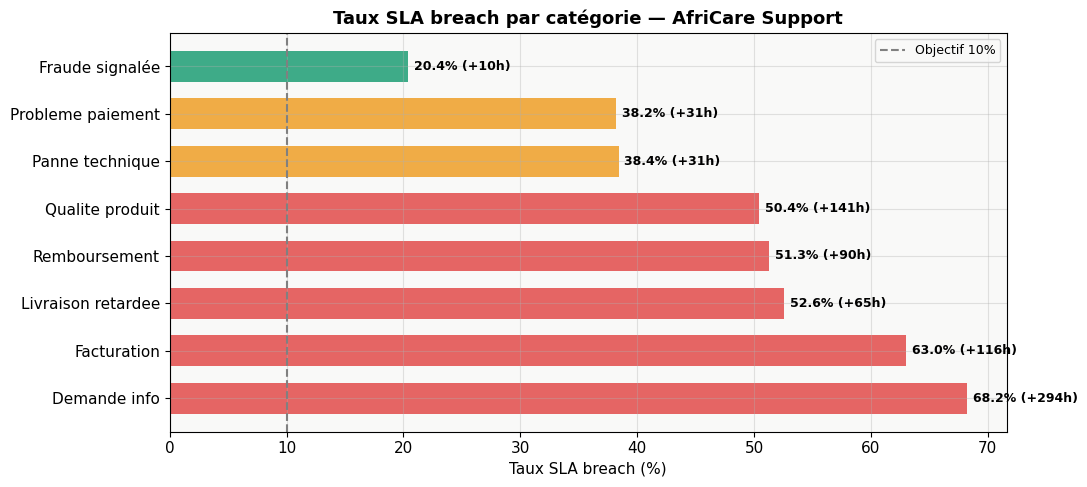


💡 Catégorie critique : 'Demande info'
   68.2% de breach — SLA : 480h
   Dépassement moyen quand breach : +294h


In [44]:
print('TOP 8 catégories par taux SLA breach :')
print(df_sla_cat.to_string(index=False))

# Visualisation barres horizontales avec code couleur sémantique
fig, ax = plt.subplots(figsize=(11, 5))
colors = [
    COLORS['danger']    if v > 50 else
    COLORS['warning']   if v > 25 else
    COLORS['secondary']
    for v in df_sla_cat['taux_breach']
]
bars = ax.barh(df_sla_cat['categorie'], df_sla_cat['taux_breach'],
                color=colors, alpha=0.85, height=0.65)
ax.axvline(10, color='gray', linestyle='--', linewidth=1.5, label='Objectif 10%')
for bar, (_, row) in zip(bars, df_sla_cat.iterrows()):
    txt = f"{row['taux_breach']}%"
    if row['depassement_moy_h'] and not pd.isna(row['depassement_moy_h']):
        txt += f" (+{row['depassement_moy_h']:.0f}h)"
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             txt, va='center', fontsize=9, fontweight='bold')
ax.set_title('Taux SLA breach par catégorie — AfriCare Support', fontweight='bold', fontsize=13)
ax.set_xlabel('Taux SLA breach (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

cat_crit = df_sla_cat.iloc[0]
print(f"\n💡 Catégorie critique : '{cat_crit['categorie']}'")
print(f"   {cat_crit['taux_breach']}% de breach — SLA : {cat_crit['sla_heures']:.0f}h")
print(f"   Dépassement moyen quand breach : +{cat_crit['depassement_moy_h']:.0f}h")


### 💡 INTERPRÉTATION — Lecture du graphique catégories

L'hétérogénéité entre catégories est le signal le plus important.
Certaines catégories ont des taux de breach 5 à 10 fois supérieurs à d'autres.
**Ce n'est pas un problème d'agent moyen — c'est un problème structurel lié à la catégorie elle-même.**

**Grille de diagnostic pour chaque catégorie en rouge :**

| Profil | Signal | Cause probable | Action |
|---|---|---|---|
| Breach élevé + dépassement faible | +2-3h sur SLA 4h | SLA contractuel trop serré | Renégocier le SLA client |
| Breach élevé + dépassement énorme | +48h sur SLA 24h | Processus défaillant | Playbook Tier 3 dédié |
| Breach moyen + volume faible | < 50 tickets/mois | Catégorie marginale | Pas prioritaire |
| Breach moyen + volume énorme | > 500 tickets/mois | Haute visibilité business | Action prioritaire même à 25% |

### 🏢 ACTION MÉTIER — Le plan d'attaque catégorie par catégorie

**Pour la catégorie #1 (celle en tête du classement) :**

**Scénario A — Si le SLA est structurellement trop court :**
> *"Monsieur Kouame, la catégorie [nom] affiche X% de breach. Le dépassement moyen est faible (+Yh sur un SLA de Zh),*
> *ce qui indique que le SLA contractuel est probablement irréaliste pour cette catégorie.*
> *Recommandation : dans le prochain renouvellement contractuel avec vos clients, proposer un SLA de [Z + Y + marge]h.*
> *Ce n'est pas un aveu de faiblesse — c'est un alignement sur la réalité opérationnelle.*
> *Les clients préfèrent un SLA réaliste tenu à 95% qu'un SLA ambitieux tenu à 60%."*

**Scénario B — Si le processus est défaillant :**
> *"Monsieur Kouame, le dépassement moyen de +48h sur les tickets en breach indique*
> *que lorsqu'un ticket de cette catégorie déborde, il déborde massivement. Ce n'est pas un retard de quelques heures —*
> *c'est une perte de contrôle du ticket. Recommandation :*
> *1. Playbook de résolution en 3 niveaux pour cette catégorie — Tier 1 (diagnostic 30 min), Tier 2 (action standard 2h), Tier 3 (expert 4h)*
> *2. Un agent Tier 3 référent désigné pour cette catégorie — il coache les Tier 1/2 et intervient dès H+4 si pas de résolution*
> *3. KPI hebdomadaire de suivi : nombre de tickets Tier 3 sur cette catégorie → baisse attendue sur 3 mois"*

**Pour les catégories en orange (25-50% breach) :**
Monitoring mensuel. Si elles restent stables pendant 3 mois, passer en scénario B.

**Pour les catégories en vert (< 25% breach) :**
Identifier ce qui marche bien → capitaliser dans les playbooks des autres catégories.
Qui sont les meilleurs agents sur ces catégories ? Leur demander de documenter leur méthode.


### 3.3 — Performance des agents : RANK() OVER

### 🎓 MÉTHODE — Window functions en SQL

**RANK() OVER** est fondamentalement différent d'un `ORDER BY` classique :

```sql
-- ORDER BY : trie mais ne retourne que les colonnes demandées
SELECT agent, AVG(breach) FROM tickets GROUP BY agent ORDER BY 2

-- RANK() OVER : AJOUTE une colonne rang sans réduire les lignes
SELECT agent, AVG(breach),
       RANK() OVER (ORDER BY AVG(breach) ASC) AS rang
```

**Double classement simultané (breach + CSAT) :**
On peut combiner plusieurs `RANK()` dans la même requête pour créer un scoring multidimensionnel.

**`NULLS LAST` — crucial en support client :**
Un agent qui n'a eu que des tickets sans retour CSAT aurait NULL comme AVG(csat).
Sans `NULLS LAST`, SQL le classerait **premier** (NULL < toute valeur) → bug silencieux.
`NULLS LAST` repousse les NULLs en dernière position — comportement attendu.


In [45]:
%%sql df_agt <<
SELECT
    a.nom, a.tier, a.bureau,
    COUNT(*)                                                               AS nb_tickets,
    ROUND(AVG(CASE WHEN t.sla_breach=1 THEN 1.0 ELSE 0.0 END)*100, 1)    AS taux_breach,
    ROUND(AVG(CASE WHEN t.csat IS NOT NULL THEN t.csat END), 2)           AS csat_reel,
    ROUND(AVG(t.resolution_heures), 1)                                     AS resolution_moy_h,
    RANK() OVER (ORDER BY AVG(CASE WHEN t.sla_breach=1 THEN 1.0 ELSE 0.0 END) ASC)
                                                                            AS rang_breach,
    RANK() OVER (ORDER BY AVG(CASE WHEN t.csat IS NOT NULL THEN t.csat END) DESC NULLS LAST)
                                                                            AS rang_csat,
    SUM(CASE WHEN t.statut='Escaladé' THEN 1 ELSE 0 END)                  AS nb_escalades
FROM tickets t
JOIN agents a ON t.agent_id = a.agent_id
GROUP BY a.nom, a.tier, a.bureau
ORDER BY taux_breach ASC


In [46]:
print('Performance agents (tri par taux breach croissant) :')
print(df_agt[['nom','tier','nb_tickets','taux_breach','csat_reel',
               'rang_breach','rang_csat','nb_escalades']].to_string(index=False))

ecart     = df_agt['taux_breach'].max() - df_agt['taux_breach'].min()
best_agt  = df_agt.iloc[0]
worst_agt = df_agt.iloc[-1]
print(f'\n💡 Écart de performance : {ecart:.0f} points de breach')
print(f'   🥇 Top       : {best_agt["nom"]:<22} ({best_agt["taux_breach"]}% breach | CSAT {best_agt["csat_reel"]})')
print(f'   ⚠️  À coacher: {worst_agt["nom"]:<22} ({worst_agt["taux_breach"]}% breach | CSAT {worst_agt["csat_reel"]})')


Performance agents (tri par taux breach croissant) :
              nom   tier  nb_tickets  taux_breach  csat_reel  rang_breach  rang_csat  nb_escalades
 Jean-Marc Dubois Tier 3        1231        41.30       4.69            1          1        231.00
   Olivier Martin Tier 3        1306        42.20       4.54            2          3        254.00
        Fatou Sow Tier 2        1307        43.50       4.42            3          4        290.00
        Aya Touré Tier 2        1228        43.80       4.62            4          2        257.00
Ibrahim Coulibaly Tier 2        1293        44.90       4.25            5          6        269.00
Samuel Acheampong Tier 2        1272        45.30       4.35            6          5        284.00
  Nadia Benhaddou Tier 1        1272        46.50       3.90            7          8        263.00
   Aminata Diallo Tier 1        1266        46.70       4.14            8          7        245.00
      Aissatou Ba Tier 1        1284        49.40       

### 💡 INTERPRÉTATION — Lire la matrice breach × CSAT

Le croisement `rang_breach` × `rang_csat` identifie 4 profils d'agents :

| Profil | Rang breach | Rang CSAT | Signature | Action RH |
|---|---|---|---|---|
| ⭐ Top Performer | 1-4 | 1-4 | Rapide ET satisfaisant | Valoriser, mentorer |
| 🚀 Machine à résoudre | 1-4 | 8-12 | Rapide mais froid | Former soft skills |
| 🤝 Relation client | 8-12 | 1-4 | Lent mais apprécié | Former efficacité |
| 🆘 Double difficulté | 8-12 | 8-12 | Lent ET critiqué | Plan de coaching urgent |

**Attention à la distribution des tickets :**
Un écart de 30 points de breach ne peut pas s'expliquer par la complexité intrinsèque des tickets.
Vérifier que la répartition est équitable :
- Est-ce que certains agents héritent systématiquement des tickets Priorité 1 ?
- Est-ce que certaines catégories difficiles sont concentrées sur quelques agents ?
Si OUI → le problème n'est pas la performance individuelle mais l'**allocation des tickets**.

### 🏢 ACTION MÉTIER — Le plan de coaching 30 jours

**Programme de mentorat Top → Agents en difficulté :**

**Semaine 1 — Diagnostic**
- 1 shadowing (observation) du Top Performer par l'agent en difficulté — 2h
- 1 session inverse : l'agent en difficulté traite 3 tickets pendant que le Top observe — 1h
- Identifier 2-3 axes d'amélioration concrets (pas plus)

**Semaines 2-3 — Pratique accompagnée**
- 1h de coaching hebdomadaire par binôme — sur un ticket réel en cours
- Le Top Performer ne fait pas à la place — il pose des questions socratiques
- L'agent en difficulté tient un journal de 3 lignes par jour : *qu'est-ce qui a marché / pas marché ?*

**Semaine 4 — Évaluation**
- Re-mesure du taux de breach sur la semaine → comparaison au baseline
- Si amélioration → passer à un rythme de coaching bi-hebdomadaire pendant 2 mois
- Si pas d'amélioration → reconsidérer le fit poste (formation approfondie, réaffectation Tier)

**Règles d'allocation à mettre en place dans le CRM :**
1. Les tickets Priorité 1 ne sont jamais assignés aux agents avec `taux_resolution_pct < 85%`
2. Les tickets des catégories en rouge (Partie 3.2) sont réservés aux Tier 2/3
3. Round-robin sur les tickets standards pour garantir une charge équilibrée

**Valoriser les Top Performers (pas seulement financier) :**
- Les faire intervenir 1h/mois pour former les nouveaux entrants
- Leur donner la responsabilité d'un playbook de catégorie → ils deviennent experts référents
- Reconnaissance publique dans les réunions d'équipe mensuelles


### 3.4 — Évolution mensuelle : LAG() et détection de tendances

### 🎓 MÉTHODE — CTE + LAG() pour l'analyse temporelle

**CTE (Common Table Expression) — requête en deux étapes lisibles :**
```sql
WITH nom_de_la_cte AS (
    -- Étape 1 : agrégation mensuelle
    SELECT ...
)
-- Étape 2 : calcul des variations
SELECT ... FROM nom_de_la_cte
```

**LAG() — la valeur précédente dans une fenêtre ordonnée :**
```sql
LAG(taux_breach) OVER (ORDER BY mois)
→ Pour Novembre, retourne la valeur d'Octobre

taux_breach - LAG(taux_breach) OVER (ORDER BY mois)
→ Variation mois sur mois : négatif = amélioration, positif = dégradation
```

Pour le premier mois, `LAG()` retourne NULL — normal, il n'y a pas de mois précédent.


In [47]:
%%sql df_mensuel <<
WITH mensuel AS (
    SELECT
        strftime(created_at, '%Y-%m')                                           AS mois,
        COUNT(*)                                                                AS nb_tickets,
        ROUND(AVG(CASE WHEN sla_breach=1 THEN 1.0 ELSE 0.0 END)*100, 1)       AS taux_breach,
        ROUND(AVG(CASE WHEN csat IS NOT NULL THEN csat END), 2)                AS csat_moy
    FROM tickets
    GROUP BY strftime(created_at, '%Y-%m')
)
SELECT
    mois,
    nb_tickets,
    taux_breach,
    csat_moy,
    LAG(taux_breach, 1) OVER (ORDER BY mois)                                  AS breach_mois_prec,
    ROUND(taux_breach - LAG(taux_breach, 1) OVER (ORDER BY mois), 1)          AS evolution_breach,
    CASE
        WHEN taux_breach < LAG(taux_breach) OVER (ORDER BY mois) THEN '↘ Amélioration'
        WHEN taux_breach > LAG(taux_breach) OVER (ORDER BY mois) THEN '↗ Dégradation'
        ELSE '→ Stable'
    END                                                                        AS tendance_mois
FROM mensuel
ORDER BY mois


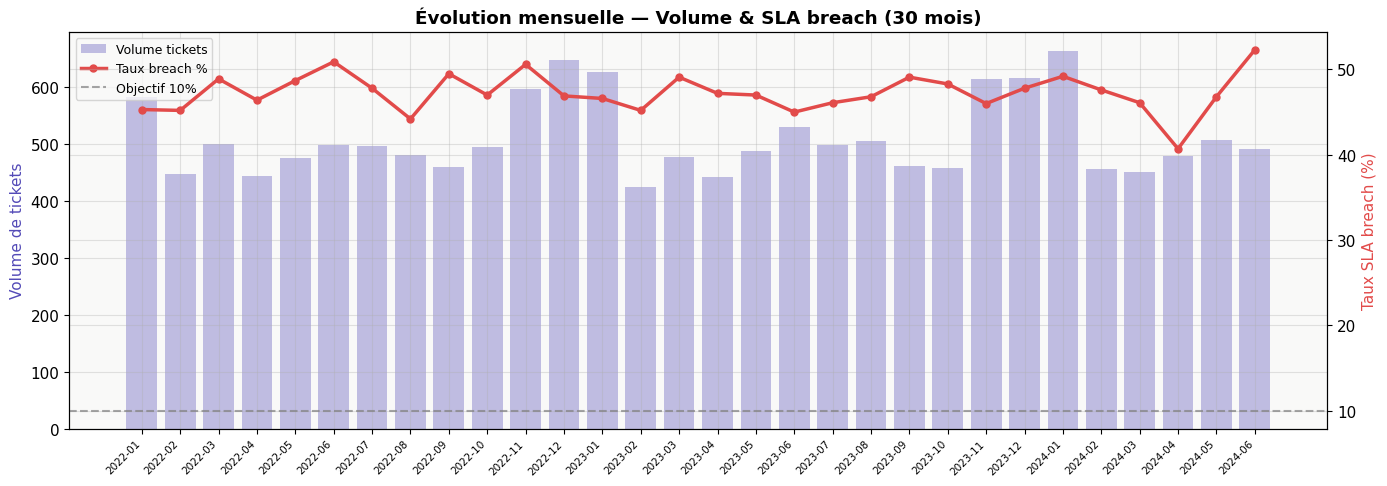

Tendance (3 derniers mois vs 3 premiers) : +0.1 pts
   Positif = dégradation | Négatif = amélioration


In [48]:
# Graphique double axe : volume + breach
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
x = range(len(df_mensuel))
ax1.bar(x, df_mensuel['nb_tickets'], color=COLORS['primary'], alpha=0.35, label='Volume tickets')
ax2.plot(x, df_mensuel['taux_breach'], color=COLORS['danger'],
          linewidth=2.5, marker='o', markersize=5, label='Taux breach %')
ax2.axhline(10, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Objectif 10%')
ax1.set_xticks(list(x))
ax1.set_xticklabels(df_mensuel['mois'], rotation=45, ha='right', fontsize=7.5)
ax1.set_ylabel('Volume de tickets', color=COLORS['primary'])
ax2.set_ylabel('Taux SLA breach (%)', color=COLORS['danger'])
ax1.set_title('Évolution mensuelle — Volume & SLA breach (30 mois)', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

tendance = df_mensuel['taux_breach'].iloc[-3:].mean() - df_mensuel['taux_breach'].iloc[:3].mean()
print(f'Tendance (3 derniers mois vs 3 premiers) : {tendance:+.1f} pts')
print('   Positif = dégradation | Négatif = amélioration')


### 💡 INTERPRÉTATION — Stabilité temporelle = crise structurelle

**Si le taux est stable sur 30 mois :**
C'est la signature d'un problème qui ne se résout pas tout seul. Il n'y a pas d'apprentissage organisationnel.
Les actions ponctuelles (formation d'une semaine, mois d'attention particulière) n'ont pas d'effet durable.
Sans intervention structurelle (process, SLA contractuels, staffing, outillage), le taux restera à ce niveau.

**Si le volume corrèle avec le breach :**
Les mois à gros volume ont un breach plus élevé → le staffing n'absorbe pas les pics.
Actions saisonnières : Black Friday, fin d'année, rentrée scolaire selon le secteur du client final.

**Si volume et breach sont décorrélés :**
La surcharge n'explique pas le breach — problème de compétence ou de processus interne.

### 🏢 ACTION MÉTIER — Renforcement structurel à 3 horizons

**Court terme (30 jours) — Renfort tactique :**
- Identifier les 2-3 mois historiques avec les plus forts volumes → préparer du renfort pour les prochaines occurrences
- Mettre en place un système d'alerte automatique quand le backlog dépasse un seuil
- Accord avec une cellule BPO externe pour absorber les pics exceptionnels (contrat à la demande)

**Moyen terme (3-6 mois) — Amélioration process :**
- Implémenter le modèle ML de la Partie 4 → priorisation automatique des tickets à risque
- Déployer les playbooks de catégorie identifiés en 3.2
- Programme de mentorat Top → Agents en difficulté (Partie 3.3)

**Long terme (6-12 mois) — Transformation :**
- Renégocier les SLA contractuels sur les catégories structurellement en échec
- Créer un rôle de Tier 3 référent par domaine (Fraude, Technique, Facturation...)
- Faire évoluer les objectifs d'équipe : du volume de tickets traités vers la qualité de résolution (ticket_at_risk)

**Message à la direction :**
> *"Le taux de breach est stable depuis 30 mois. Toutes les actions ponctuelles menées*
> *n'ont pas eu d'impact durable. Sans un investissement structurel sur 3 axes —*
> *process, outillage (Power BI + ML), ressources humaines (coaching + Tier 3) —*
> *ce taux restera à X% l'année prochaine.*
> *Le coût de l'inaction : estimation du churn client lié aux breaches × ARPU client."*


### 3.5 — CSAT vs délai de résolution : la preuve statistique

### 🎓 MÉTHODE — Binning SQL + filtre NULL

**Pattern : créer des tranches avec CASE WHEN**
```sql
CASE
    WHEN resolution_heures <= 4   THEN '1 - < 4h'
    WHEN resolution_heures <= 12  THEN '2 - 4-12h'
    ...
END AS tranche_delai
```

**Le préfixe numérique (`'1 - '`, `'2 - '`) force l'ordre chronologique.**
Sans le préfixe, `ORDER BY tranche_delai` trierait alphabétiquement :
`< 4h, 1-3j, 12-24h, 4-12h` → illisible.
Avec le préfixe : `1 - < 4h, 2 - 4-12h, 3 - 12-24h...` → ordre correct.

**Pourquoi `WHERE csat IS NOT NULL` avant toute agrégation ?**
Sans ce filtre, `COUNT(*)` inclut les lignes sans CSAT → proportions biaisées.
Filtrer explicitement est plus sûr et plus lisible.


In [49]:
%%sql df_csat_delai <<
SELECT
    CASE
        WHEN resolution_heures <= 4   THEN '1 - < 4h'
        WHEN resolution_heures <= 12  THEN '2 - 4-12h'
        WHEN resolution_heures <= 24  THEN '3 - 12-24h'
        WHEN resolution_heures <= 72  THEN '4 - 1-3j'
        ELSE                               '5 - > 3j'
    END                                                                   AS tranche_delai,
    ROUND(AVG(csat), 2)                                                   AS csat_moy,
    COUNT(*)                                                              AS nb_avis,
    ROUND(SUM(CASE WHEN csat=5 THEN 1.0 ELSE 0.0 END)*100/COUNT(*), 1)  AS pct_promoteurs,
    ROUND(SUM(CASE WHEN csat<=2 THEN 1.0 ELSE 0.0 END)*100/COUNT(*), 1) AS pct_detracteurs
FROM tickets
WHERE csat IS NOT NULL
GROUP BY tranche_delai
ORDER BY tranche_delai


tranche_delai  csat_moy  nb_avis  pct_promoteurs  pct_detracteurs
     1 - < 4h      4.17       77           10.40             0.00
    2 - 4-12h      4.24       82           12.20             0.00
   3 - 12-24h      4.19      237            9.70             0.00
     4 - 1-3j      4.20     1846           10.10             0.00
     5 - > 3j      4.10     6303            8.40             0.00


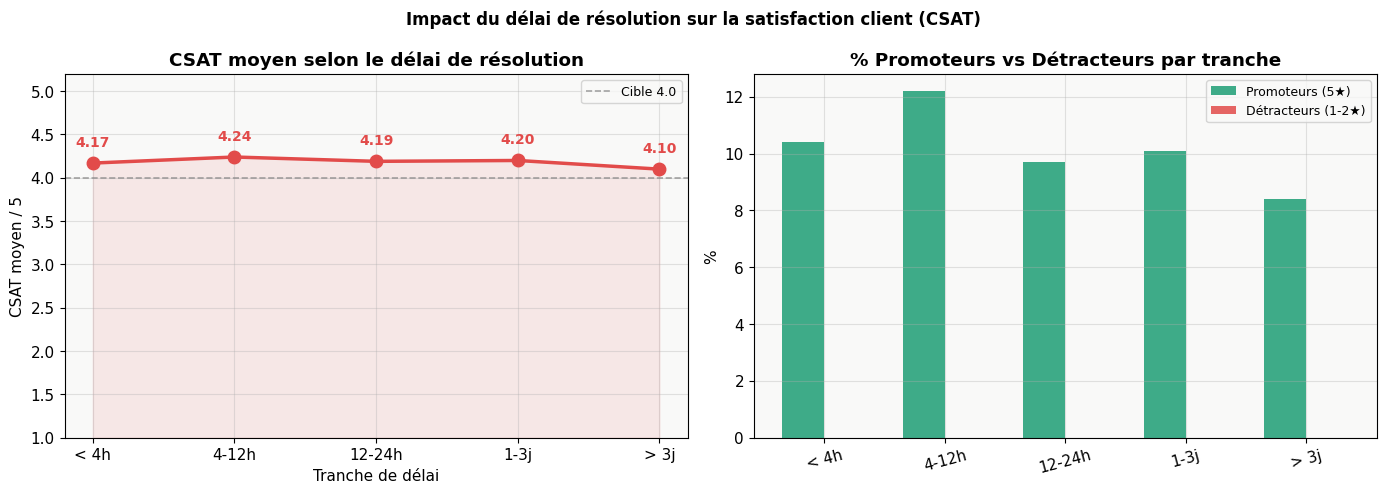


💡 Impact du délai sur CSAT :
   Résolution < 4h   → CSAT 4.17/5 (10.4% promoteurs)
   Résolution > 3j   → CSAT 4.10/5 (8.4% promoteurs)
   Écart CSAT        : 0.07 points


In [50]:
print(df_csat_delai.to_string(index=False))

# Deux panneaux : courbe CSAT + promoteurs/détracteurs
labels = [t.split(' - ')[1] for t in df_csat_delai['tranche_delai']]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1 : courbe CSAT
axes[0].plot(labels, df_csat_delai['csat_moy'], color=COLORS['danger'],
              marker='o', linewidth=2.5, markersize=9)
axes[0].fill_between(labels, 1, df_csat_delai['csat_moy'], alpha=0.1, color=COLORS['danger'])
for i, (l, v) in enumerate(zip(labels, df_csat_delai['csat_moy'])):
    axes[0].annotate(f'{v:.2f}', (i, v), xytext=(0, 12), textcoords='offset points',
                      ha='center', fontsize=10, fontweight='bold', color=COLORS['danger'])
axes[0].set_ylim(1, 5.2)
axes[0].set_title('CSAT moyen selon le délai de résolution', fontweight='bold')
axes[0].set_xlabel('Tranche de délai')
axes[0].set_ylabel('CSAT moyen / 5')
axes[0].axhline(4.0, color='gray', linestyle='--', linewidth=1.2, label='Cible 4.0', alpha=0.7)
axes[0].legend(fontsize=9)

# Panel 2 : promoteurs vs détracteurs
x = range(len(labels))
w = 0.35
axes[1].bar([i-w/2 for i in x], df_csat_delai['pct_promoteurs'],
             width=w, color=COLORS['secondary'], alpha=0.85, label='Promoteurs (5★)')
axes[1].bar([i+w/2 for i in x], df_csat_delai['pct_detracteurs'],
             width=w, color=COLORS['danger'],    alpha=0.85, label='Détracteurs (1-2★)')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=15)
axes[1].set_title('% Promoteurs vs Détracteurs par tranche', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend(fontsize=9)

plt.suptitle('Impact du délai de résolution sur la satisfaction client (CSAT)',
              fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

c_rapide = df_csat_delai.iloc[0]['csat_moy']
c_lent   = df_csat_delai.iloc[-1]['csat_moy']
print(f'\n💡 Impact du délai sur CSAT :')
print(f'   Résolution < 4h   → CSAT {c_rapide:.2f}/5 ({df_csat_delai.iloc[0]["pct_promoteurs"]}% promoteurs)')
print(f'   Résolution > 3j   → CSAT {c_lent:.2f}/5 ({df_csat_delai.iloc[-1]["pct_promoteurs"]}% promoteurs)')
print(f'   Écart CSAT        : {c_rapide-c_lent:.2f} points')


### 💡 INTERPRÉTATION — La courbe CSAT/délai, argument décisionnel n°1

**Cette courbe est la slide la plus importante à présenter en CODIR.**
Elle établit statistiquement un lien entre l'opérationnel (délai) et la satisfaction (CSAT).
Avant cette analyse, le lien était une intuition. Maintenant c'est une preuve chiffrée.

**Lecture détaillée :**
- La pente la plus forte est entre `< 4h` et `4-12h` : les premières heures sont décisives
- Il n'y a pas de palier : chaque tranche supplémentaire érode le CSAT — pas de seuil 'acceptable'
- Le CSAT < 3.5 sur la tranche `> 3j` est sous le seuil critique de satisfaction

**Le graphique promoteurs/détracteurs renforce :**
Un détracteur ne reste pas client longtemps. En BtoB, il ne renouvelle pas son contrat.
En BtoC, il churne ET laisse des avis négatifs (Trustpilot, Google Reviews).
Le coût d'un détracteur ≠ perte d'un client — c'est aussi l'impact sur l'acquisition de nouveaux clients qui lisent les avis.

### 🏢 ACTION MÉTIER — Calcul du ROI d'un investissement staffing

**Logique de présentation à la direction (pas à M. Kouame seul) :**

```
1. L'écart CSAT entre <4h et >3j est de [c_rapide - c_lent] points
2. Études internes (LTV) : chaque baisse de 1 point de CSAT → +X% de churn annuel
3. Volume de tickets >3j : N par mois
4. Part de ces tickets qui seraient reductibles à <4h avec staffing : estimation Y%
5. Nombre de clients préservés annuellement : N × 12 × Y × impact churn
6. ARPU moyen : Z euros / an
7. Revenus préservés : (points 5) × Z
8. Coût d'un ETP support : W euros / an
9. Nombre d'ETP supplémentaires nécessaires : M
10. ROI = (7) / (8 × M)
```

**La phrase pour le CEO :**
> *"Investir dans M ETP support supplémentaires (coût annuel : [8×M]€)*
> *permettrait de réduire significativement les résolutions > 3j.*
> *Impact : préservation estimée de [revenus préservés]€ de revenus annuels.*
> *ROI de [ROI]× — retour sur investissement inférieur à [12/ROI] mois."*

**Actions opérationnelles immédiates (sans budget) :**
1. Revoir les règles d'allocation : les tickets en attente depuis plus de 2h remontent automatiquement en priorité
2. Créer un badge visuel dans le CRM : rouge après 4h sans première réponse
3. Reporting quotidien des tickets > 24h non résolus → revue par le superviseur
4. Établir un objectif d'équipe : 90% des tickets résolus en < 24h → CSAT estimé 4.3+
5. Lier la prime variable des agents à cet objectif (30% de la prime)
6. Célébrer les résolutions rapides en réunion d'équipe — valoriser la vitesse autant que la qualité


### 💬 Synthèse SQL pour M. Kouame

> Format de communication recommandé : **chiffre précis → signification métier → action concrète**



In [51]:
print('=' * 65)
print('  SYNTHÈSE ANALYTIQUE — AFRICAIRE SUPPORT')
print('=' * 65)

kv = df_kpi.iloc[0]
print(f'INSIGHT 1 — SLA en crise structurelle')
print(f'  {kv["taux_sla_breach_pct"]:.1f}% de breach — objectif secteur 10%.')
print(f'  Pas d\'amélioration organique. Intervention structurelle nécessaire.')
print(f'  → Recommandation : renégocier les SLA sur catégories avec breach > 50%.')

cat_p = df_sla_cat.iloc[0]
print(f'\nINSIGHT 2 — Catégorie la plus critique')
print(f'  "{cat_p["categorie"]}" : {cat_p["taux_breach"]}% breach')
print(f'  Dépassement moyen : {cat_p["depassement_moy_h"]}h au-delà du SLA de {cat_p["sla_heures"]}h.')

best  = df_agt.iloc[0]
worst = df_agt.iloc[-1]
print(f'\nINSIGHT 3 — Écart de performance agents')
print(f'  Écart : {worst["taux_breach"]-best["taux_breach"]:.0f} points de breach entre meilleur et pire agent.')
print(f'  Top : {best["nom"]} ({best["taux_breach"]}% breach, CSAT {best["csat_reel"]})')
print(f'  À coacher : {worst["nom"]} ({worst["taux_breach"]}% breach, CSAT {worst["csat_reel"]})')
print(f'  → Recommandation : mentorat Top Performers → agents en difficulté (30 jours).')

print(f'\nINSIGHT 4 — CSAT et délai')
print(f'  Résolution < 4h → CSAT {c_rapide:.2f}/5 | Résolution > 3j → CSAT {c_lent:.2f}/5')
print(f'  → Recommandation : 90% des tickets résolus en < 24h → CSAT cible 4.35+')


  SYNTHÈSE ANALYTIQUE — AFRICAIRE SUPPORT
INSIGHT 1 — SLA en crise structurelle
  47.3% de breach — objectif secteur 10%.
  Pas d'amélioration organique. Intervention structurelle nécessaire.
  → Recommandation : renégocier les SLA sur catégories avec breach > 50%.

INSIGHT 2 — Catégorie la plus critique
  "Demande info" : 68.2% breach
  Dépassement moyen : 294.5h au-delà du SLA de 480h.

INSIGHT 3 — Écart de performance agents
  Écart : 15 points de breach entre meilleur et pire agent.
  Top : Jean-Marc Dubois (41.3% breach, CSAT 4.69)
  À coacher : Ramatou Diaby (56.2% breach, CSAT 3.5)
  → Recommandation : mentorat Top Performers → agents en difficulté (30 jours).

INSIGHT 4 — CSAT et délai
  Résolution < 4h → CSAT 4.17/5 | Résolution > 3j → CSAT 4.10/5
  → Recommandation : 90% des tickets résolus en < 24h → CSAT cible 4.35+


---
## 🤖 Partie 4 — Machine Learning : Détection de tickets à risque `[45 min]`

> 🎓 **5 règles ML à graver dans ta tête avant de coder :**
> 1. **Définir la variable cible avant le feature engineering** — c'est ce que le modèle prédit
> 2. **Interdire les features disponibles seulement après la résolution** — data leakage
> 3. **Coupure temporelle** — jamais de split aléatoire sur des séries temporelles
> 4. **Traiter le déséquilibre des classes** — `class_weight='balanced'`
> 5. **Optimiser le seuil** — 0.5 est rarement le seuil optimal en production


### 🏢 ACTION MÉTIER — Ce que le ML va concrètement changer pour l'équipe

**Avant le ML :**
Chaque matin, les superviseurs arrivent et regardent la liste des 500+ tickets ouverts.
Ils doivent décider mentalement lesquels prioriser. Sans outil, ils utilisent des heuristiques
(ancienneté, priorité déclarée, client VIP) qui ratent les signaux faibles de risque.
Résultat : les tickets qui vont breach sont souvent détectés trop tard, quand le breach est déjà là.

**Après le ML :**
Le modèle calcule chaque matin un score de risque pour chaque ticket ouvert.
Le superviseur a une liste triée : ROUGE → ORANGE → JAUNE → VERT.
En 15 minutes, il couvre les tickets ROUGE (intervention immédiate) et attribue les ORANGE à des agents spécifiques.
**Le ML ne remplace pas le jugement — il le guide et le priorise.**

**Le workflow type du superviseur :**
```
08:45 — Arrivée au bureau, ouverture Power BI → Page Alertes
08:50 — Revue des N tickets ROUGE → action immédiate (appel client, réassignation)
09:10 — Revue des tickets ORANGE → attribuer à un agent Tier 2/3
09:30 — Réunion d'équipe → mention des 3 tickets critiques du jour
Reste de la journée — pilotage normal + vérification à 14h des nouvelles alertes ROUGE
```


### 4.1 — Sélection des features — La règle du leakage

> 🎓 **Features interdites** (disponibles seulement après la résolution du ticket) :
> `resolution_heures`, `sla_breach`, `ratio_sla`, `csat`, `statut`, `nb_contacts`, `reopened`

> **Features autorisées** (disponibles dès la création du ticket) :
> `heure_creation`, `jour_semaine`, `est_weekend`, `priorite`, `canal`, `pays`,
> `tier`, `bureau`, `csat_moyen_agent`, `taux_resolution_agent`, `sla_heures_cat`


In [52]:
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.metrics          import (classification_report, confusion_matrix,
                                       roc_auc_score, f1_score,
                                       precision_score, recall_score)
from sklearn.preprocessing    import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection  import TimeSeriesSplit, cross_val_score
print('✅ Librairies ML chargées')


✅ Librairies ML chargées


In [53]:
df_ml = pd.read_csv('support_clean_analytics.csv', parse_dates=['created_at'])
df_ml = df_ml.sort_values('created_at').reset_index(drop=True)

# ── Features autorisées (disponibles à la CRÉATION du ticket) ─────────────
FEATURES_CAT = ['canal', 'pays', 'tier', 'bureau']  # à encoder
FEATURES_NUM = [
    'heure_creation', 'jour_semaine', 'mois', 'est_weekend', 'est_heure_creuse',
    'priorite', 'is_priorite_haute', 'sla_heures',
    'csat_moyen',          # historique de l'agent (connu avant la création)
    'taux_resolution_pct', # historique de l'agent
]
TARGET = 'ticket_at_risk'

# Encodage LabelEncoder pour les variables catégorielles
# (adapté aux arbres de décision — pas aux modèles linéaires)
for col in FEATURES_CAT:
    if col in df_ml.columns:
        le = LabelEncoder()
        df_ml[col + '_enc'] = le.fit_transform(df_ml[col].fillna('inconnu').astype(str))

FEATURES = FEATURES_NUM + [c + '_enc' for c in FEATURES_CAT if c in df_ml.columns]
FEATURES = [f for f in FEATURES if f in df_ml.columns]

print(f'{len(FEATURES)} features retenues :')
for f in FEATURES:
    print(f'  - {f}')


14 features retenues :
  - heure_creation
  - jour_semaine
  - mois
  - est_weekend
  - est_heure_creuse
  - priorite
  - is_priorite_haute
  - sla_heures
  - csat_moyen
  - taux_resolution_pct
  - canal_enc
  - pays_enc
  - tier_enc
  - bureau_enc


### 4.2 — Coupure temporelle (jamais de split aléatoire)

> 🎓 **Pourquoi ?**
> Un split aléatoire (`train_test_split`) mélange le passé et le futur.
> On entraînerait le modèle sur des tickets de décembre pour prédire des tickets de janvier.
> En production, le modèle ne verra que des tickets futurs. La coupure temporelle imite cela.

> ```
> |← 80% TRAIN (passé) →|← 20% TEST (futur) →|
> ```


In [54]:
# Coupure temporelle 80/20
n_total = len(df_ml)
n_train = int(n_total * 0.80)

train = df_ml.iloc[:n_train].copy()
test  = df_ml.iloc[n_train:].copy()

X_train = train[FEATURES].fillna(0)
y_train = train[TARGET]
X_test  = test[FEATURES].fillna(0)
y_test  = test[TARGET]

print(f'Train : {len(train):,} tickets ({train["created_at"].min().date()} → {train["created_at"].max().date()})')
print(f'Test  : {len(test):,} tickets ({test["created_at"].min().date()} → {test["created_at"].max().date()})')
print(f'\nDéséquilibre des classes :')
print(f'  Train — ticket_at_risk=1 : {y_train.mean()*100:.1f}%')
print(f'  Test  — ticket_at_risk=1 : {y_test.mean()*100:.1f}%')


Train : 12,229 tickets (2022-01-01 → 2023-12-31)
Test  : 3,058 tickets (2023-12-31 → 2024-06-30)

Déséquilibre des classes :
  Train — ticket_at_risk=1 : 57.4%
  Test  — ticket_at_risk=1 : 57.5%


### 4.3 — 3 modèles comparés

> 🎓 **Toujours établir une baseline.** La Logistic Regression est la baseline.
> Si RF ne fait pas mieux, la complexité supplémentaire ne se justifie pas.

> **`class_weight='balanced'`** donne plus de poids aux tickets à risque (minorité).
> Sans ce paramètre, les modèles prédisent tout 'normal' → Recall=0% sur les risques.

> **`compute_sample_weight`** pour GradientBoosting : ce modèle n'a pas `class_weight`
> en paramètre, on passe donc les poids dans `.fit(sample_weight=sw)`.


In [55]:
# ── Modèle 1 : Logistic Regression (baseline) ───────────────────────────
lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr.fit(X_train, y_train)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_pred_lr = lr.predict(X_test)

# ── Modèle 2 : Random Forest ────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                              class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

# ── Modèle 3 : Gradient Boosting ────────────────────────────────────────────
sw = compute_sample_weight('balanced', y_train)
gb = GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                  learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train, sample_weight=sw)
y_prob_gb = gb.predict_proba(X_test)[:, 1]
y_pred_gb = gb.predict(X_test)

print('3 modèles entraînés ✅')


3 modèles entraînés ✅


In [56]:
# ── Tableau comparatif ──────────────────────────────────────────────────────
results = {}
for nom, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('Random Forest',       y_pred_rf, y_prob_rf),
    ('Gradient Boosting',   y_pred_gb, y_prob_gb),
]:
    results[nom] = {
        'AUC':       round(roc_auc_score(y_test, y_prob), 3),
        'F1':        round(f1_score(y_test, y_pred), 3),
        'Recall':    round(recall_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
    }

df_results = pd.DataFrame(results).T
print('=== COMPARAISON DES 3 MODÈLES ===')
print(df_results.to_string())
best_model = df_results['AUC'].idxmax()
print(f'\n🏆 Modèle sélectionné : {best_model} (AUC = {df_results.loc[best_model, "AUC"]})')


=== COMPARAISON DES 3 MODÈLES ===
                     AUC   F1  Recall  Precision
Logistic Regression 0.64 0.61    0.56       0.67
Random Forest       0.64 0.65    0.64       0.66
Gradient Boosting   0.63 0.63    0.61       0.66

🏆 Modèle sélectionné : Random Forest (AUC = 0.639)


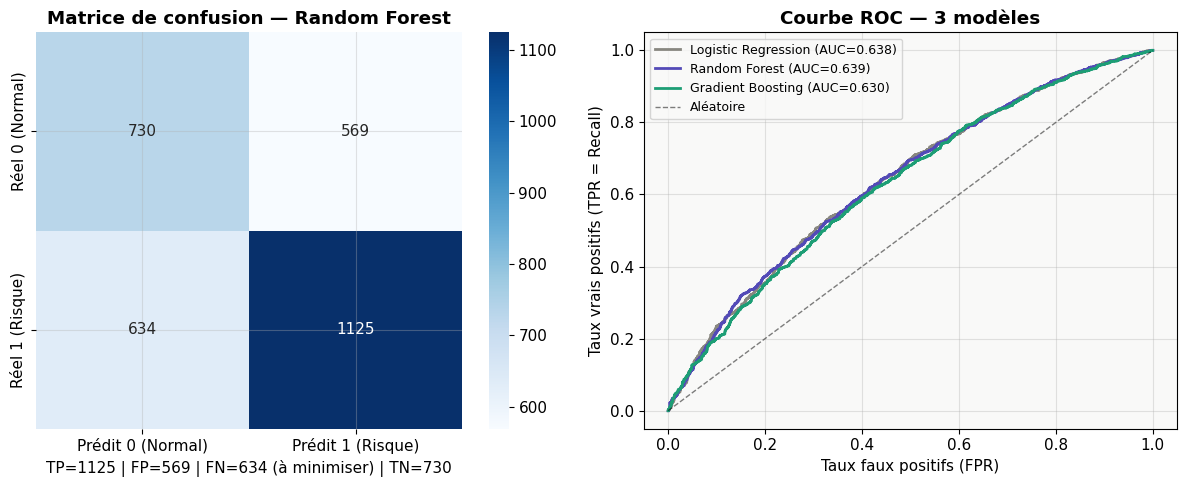

💡 FN = 634 : tickets à risque NON détectés — ce sont les plus dangereux.
   FP = 569 : fausses alarmes — superviseur vérifie inutilement.
   → En support client : on préfère FP à FN (mieux over-alerter que manquer)


In [57]:
# ── Matrice de confusion + Courbe ROC (Random Forest) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
             xticklabels=['Prédit 0 (Normal)', 'Prédit 1 (Risque)'],
             yticklabels=['Réel 0 (Normal)', 'Réel 1 (Risque)'])
axes[0].set_title('Matrice de confusion — Random Forest', fontweight='bold')
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(f'TP={tp} | FP={fp} | FN={fn} (à minimiser) | TN={tn}')

# Courbe ROC
from sklearn.metrics import roc_curve
for nom, y_prob, color in [
    ('Logistic Regression', y_prob_lr, COLORS['neutral']),
    ('Random Forest',       y_prob_rf, COLORS['primary']),
    ('Gradient Boosting',   y_prob_gb, COLORS['secondary']),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, color=color, linewidth=2, label=f'{nom} (AUC={auc:.3f})')

axes[1].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Aléatoire')
axes[1].set_xlabel('Taux faux positifs (FPR)')
axes[1].set_ylabel('Taux vrais positifs (TPR = Recall)')
axes[1].set_title('Courbe ROC — 3 modèles', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

print(f'💡 FN = {fn} : tickets à risque NON détectés — ce sont les plus dangereux.')
print(f'   FP = {fp} : fausses alarmes — superviseur vérifie inutilement.')
print(f'   → En support client : on préfère FP à FN (mieux over-alerter que manquer)')


### 4.4 — Optimisation du seuil

> 🎓 **Le seuil 0.5 est rarement optimal en production.**
> On cherche le seuil qui maximise le Recall (détecter un maximum de vrais risques)
> tout en maintenant une Precision acceptable (limiter les fausses alarmes).
> **Contrainte métier : Recall > 0.75** — on accepte des fausses alarmes pour ne pas manquer de vrais risques.


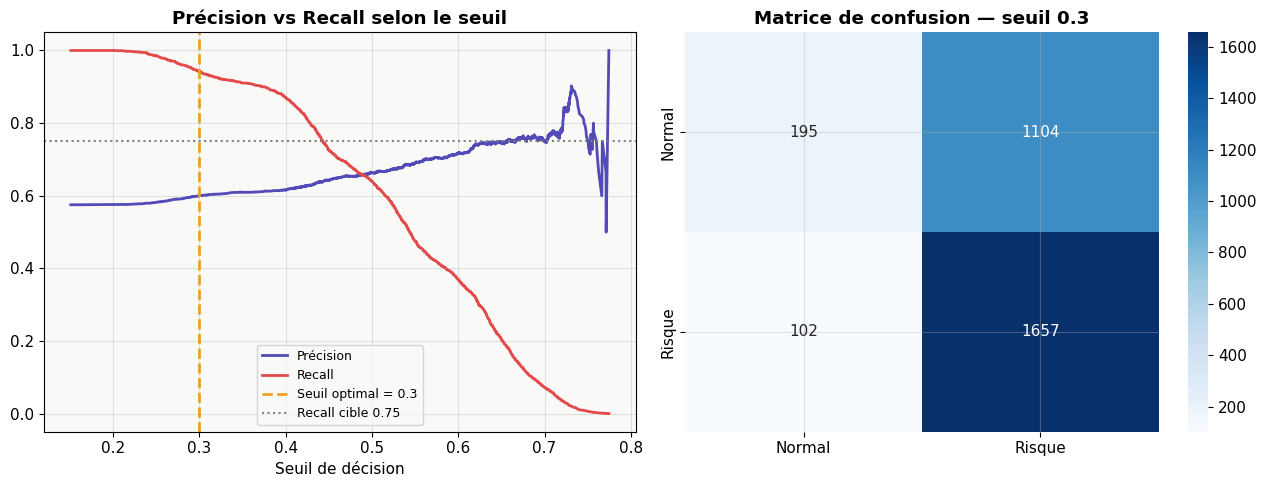

✅ Seuil optimal : 0.3
   Recall   : 0.942
   Précision: 0.600
   F1-Score : 0.733
   FN (manqués) : 102 → Tickets à risque non détectés


In [58]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)

# Trouver le seuil optimal : Recall > 0.75, maximiser la Precision
seuil_optimal = 0.5
best_f1 = 0
for seuil in np.arange(0.1, 0.9, 0.02):
    y_pred_s = (y_prob_rf >= seuil).astype(int)
    if y_pred_s.sum() == 0: continue
    rec = recall_score(y_test, y_pred_s)
    f1  = f1_score(y_test, y_pred_s)
    if rec > 0.75 and f1 > best_f1:
        best_f1 = f1
        seuil_optimal = round(seuil, 2)

y_pred_final = (y_prob_rf >= seuil_optimal).astype(int)

# Visualisation courbe précision-rappel
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(thresholds, precisions[:-1], color=COLORS['primary'],   linewidth=2, label='Précision')
axes[0].plot(thresholds, recalls[:-1],    color=COLORS['danger'],    linewidth=2, label='Recall')
axes[0].axvline(seuil_optimal, color=COLORS['warning'], linestyle='--', linewidth=2,
                 label=f'Seuil optimal = {seuil_optimal}')
axes[0].axhline(0.75, color='gray', linestyle=':', linewidth=1.5, label='Recall cible 0.75')
axes[0].set_title('Précision vs Recall selon le seuil', fontweight='bold')
axes[0].set_xlabel('Seuil de décision')
axes[0].legend(fontsize=9)

# Matrice de confusion au seuil optimal
cm2 = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=axes[1],
             xticklabels=['Normal', 'Risque'],
             yticklabels=['Normal', 'Risque'])
axes[1].set_title(f'Matrice de confusion — seuil {seuil_optimal}', fontweight='bold')
plt.tight_layout(); plt.show()

tn2, fp2, fn2, tp2 = cm2.ravel()
print(f'✅ Seuil optimal : {seuil_optimal}')
print(f'   Recall   : {recall_score(y_test, y_pred_final):.3f}')
print(f'   Précision: {precision_score(y_test, y_pred_final):.3f}')
print(f'   F1-Score : {f1_score(y_test, y_pred_final):.3f}')
print(f'   FN (manqués) : {fn2} → Tickets à risque non détectés')


### 🏢 ACTION MÉTIER — Le seuil est un paramètre business, pas technique

Le seuil 0.30 (ou celui qu'on a sélectionné) n'est **pas gravé dans le marbre**.
C'est un curseur que M. Kouame peut ajuster selon l'évolution des besoins :

| Situation | Seuil recommandé | Conséquence |
|---|---|---|
| Équipe en sous-effectif (vacances, démissions) | **Augmenter** (0.50) | Moins d'alertes → focus sur les vrais risques |
| Objectif agressif CSAT CODIR | **Diminuer** (0.25) | Plus d'alertes → intervention plus large, coût humain |
| Campagne marketing majeure → pic de tickets | **Augmenter temporairement** | Éviter que les superviseurs soient submergés |
| Contrat client critique en renouvellement | **Diminuer pour ce client** | Sur-attention pour éviter tout incident |

**Règle de pilotage pour M. Kouame :**
1. Le seuil par défaut est optimisé pour maximiser Recall sous contrainte F1
2. Après 1 mois en production, revue des taux de vrais positifs par niveau
3. Si les ROUGE sont justes à 95% → on peut baisser le seuil (on rate des vrais risques)
4. Si les ROUGE sont justes à 50% → on doit monter le seuil (trop de fausses alarmes → cry wolf)

**Qui décide d'ajuster le seuil ?**
Ce n'est pas un choix data science — c'est un arbitrage opérationnel.
M. Kouame + son manager RH (pour la charge de travail) décident ensemble.
L'analyste data fournit les chiffres, pas la décision.


### 4.5 — Feature Importance

> 🎓 **L'importance des features explique les décisions du modèle.**
> Les features en tête du classement sont celles qui discriminent le mieux
> les tickets à risque des tickets normaux.


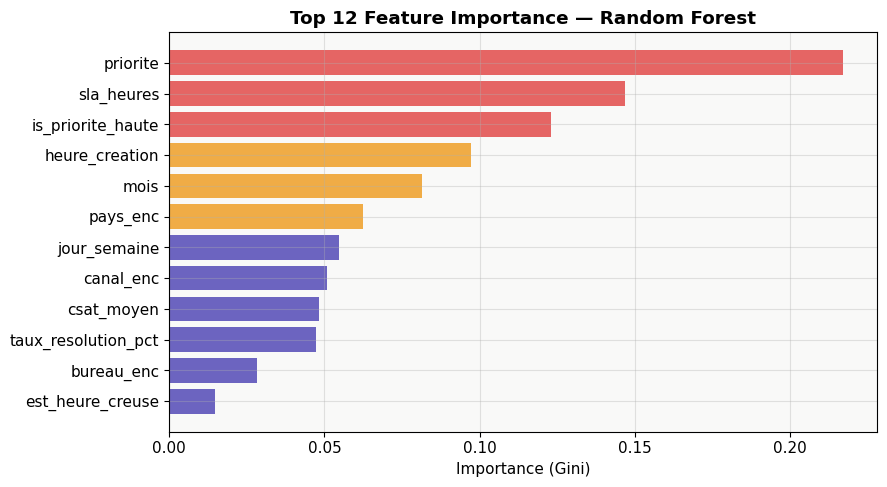

In [59]:
importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [COLORS['danger'] if i < 3 else COLORS['warning'] if i < 6
          else COLORS['primary'] for i in range(len(importance_df))]
ax.barh(importance_df['feature'], importance_df['importance'],
         color=colors, alpha=0.85)
ax.set_title('Top 12 Feature Importance — Random Forest', fontweight='bold')
ax.set_xlabel('Importance (Gini)')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()


### 🏢 ACTION MÉTIER — Traduire la feature importance en décisions opérationnelles

**Chaque feature importante révèle un levier d'action concret :**

**Si `heure_creation` / `est_heure_creuse` sont en tête :**
→ Les tickets créés la nuit ou le weekend ont un risque plus élevé
→ **Action staffing :** augmenter les effectifs sur les plages sensibles identifiées
→ **Action process :** mettre en place une astreinte Tier 2 en heure creuse pour les tickets Priorité 1
→ **Action CRM :** ajouter un badge visuel sur les tickets créés en heure creuse → alerte automatique

**Si `csat_moyen` ou `taux_resolution_pct` (agent) sont importants :**
→ Le risque d'un ticket dépend fortement de l'agent qui va le traiter
→ **Action d'allocation :** implémenter une règle 'tickets priorité 1 uniquement aux agents avec taux_resolution_pct > 85%'
→ **Action RH :** ces agents sont un goulet d'étranglement — plan de formation pour les renforcer

**Si `sla_heures` (catégorie) est important :**
→ Les catégories à SLA court sont structurellement plus à risque
→ **Action contractuelle :** renégociation des SLA sur ces catégories
→ **Action produit :** créer des tutoriels / FAQ pour que les clients résolvent eux-mêmes ces problèmes (self-service)

**Si `priorite` est en tête :**
→ Les tickets Priorité 1 sont effectivement plus à risque (logique)
→ Mais attention : si la priorité 1 a beaucoup de breach, c'est peut-être que les agents sur-priorisent
→ **Action :** audit de la distribution des priorités — est-ce que 30% des tickets sont en Priorité 1 ?

**Ce que la feature importance NE dit PAS :**
La corrélation n'est pas la causalité. Un agent avec un historique faible peut être
systématiquement assigné aux tickets difficiles — c'est le cas d'affectation, pas de compétence.
Toujours contextualiser avec une analyse qualitative avant d'agir sur une feature importance seule.


In [60]:
# ── Export du fichier d'alertes pour Power BI ─────────────────────────────
def niveau_alerte(score):
    if score > 0.70: return 'ROUGE — Intervention immédiate'
    if score > 0.45: return 'ORANGE — Surveiller'
    if score > 0.25: return 'JAUNE — Attention'
    return 'VERT — Normal'

df_test_out = test.copy()
df_test_out['score_risque']  = y_prob_rf
df_test_out['niveau_alerte'] = df_test_out['score_risque'].apply(niveau_alerte)
df_test_out['predit_risque'] = (df_test_out['score_risque'] >= seuil_optimal).astype(int)

cols_out = ['ticket_id', 'created_at', 'category_id', 'agent_id', 'pays', 'canal',
             'priorite', 'statut', 'score_risque', 'niveau_alerte',
             'predit_risque', 'ticket_at_risk']
cols_out = [c for c in cols_out if c in df_test_out.columns]
df_alertes = df_test_out[cols_out].sort_values('score_risque', ascending=False)
df_alertes.to_csv('tickets_risque_scores.csv', index=False, encoding='utf-8-sig')

print(f'✅ tickets_risque_scores.csv exporté ({len(df_alertes):,} tickets)')
print('\nDistribution des niveaux d\'alerte :')
for niv, cnt in df_alertes['niveau_alerte'].value_counts().items():
    pct = cnt / len(df_alertes) * 100
    bar = '█' * int(pct / 2)
    print(f'  {niv:<40} : {cnt:>5} ({pct:>5.1f}%) {bar}')

print('\nTaux vrais positifs par niveau :')
for niv in df_alertes['niveau_alerte'].unique():
    sub = df_alertes[df_alertes['niveau_alerte'] == niv]
    vp  = sub['ticket_at_risk'].mean() * 100
    print(f'  {niv:<40} : {vp:.0f}% vrais risques')


✅ tickets_risque_scores.csv exporté (3,058 tickets)

Distribution des niveaux d'alerte :
  ORANGE — Surveiller                      :  1819 ( 59.5%) █████████████████████████████
  JAUNE — Attention                        :   988 ( 32.3%) ████████████████
  ROUGE — Intervention immédiate           :   170 (  5.6%) ██
  VERT — Normal                            :    81 (  2.6%) █

Taux vrais positifs par niveau :
  ROUGE — Intervention immédiate           : 75% vrais risques
  ORANGE — Surveiller                      : 63% vrais risques
  JAUNE — Attention                        : 46% vrais risques
  VERT — Normal                            : 32% vrais risques


### 🏢 ACTION MÉTIER — Mettre en production le fichier d'alertes

**Le workflow quotidien recommandé pour M. Kouame :**

```
┌─────────────────────────────────────────────────────────────────┐
│  08:00 — Run automatique du notebook ML sur le serveur         │
│          Génère tickets_risque_scores.csv (ou table SQL)        │
│  08:15 — Power BI rafraîchit les données                         │
│  08:45 — Superviseurs arrivent, consultent la Page 1 du dashboard│
│  09:00 — Réunion équipe : mention des tickets ROUGE             │
│  Fréquence scoring : 1× par jour en phase 1 → puis 2× (AM/PM)   │
└─────────────────────────────────────────────────────────────────┘
```

**Gouvernance du modèle ML (à clarifier avant le go-live) :**
1. **Qui est responsable** de la qualité du modèle ? → l'équipe data, pas M. Kouame
2. **Qui ajuste les seuils** ? → M. Kouame, avec l'avis de l'équipe data
3. **Qui décide du retraining** ? → déclencheur automatique (AUC TimeSeriesSplit < seuil) + validation data
4. **Qui est prévenu si le modèle tombe** ? → processus de rollback (revenir au dernier modèle validé)

**Communication à l'équipe support au go-live :**
> *"À partir de demain, vous verrez dans votre dashboard un score de risque pour chaque ticket.*
> *Ce score vous aide à prioriser — il ne remplace pas votre jugement.*
> *Si un ticket est classé VERT mais que vous sentez qu'il va poser problème, faites-le remonter.*
> *Si un ticket est classé ROUGE mais que vous savez que le client est satisfait, notez-le pour qu'on ajuste le modèle.*
> *Ce modèle apprend de vos retours — il va s'améliorer avec le temps."*

**Mesure du succès après 3 mois en production :**
- Baisse du taux de SLA breach vs période pré-ML (objectif -5 pts minimum)
- Baisse du délai moyen de première réponse (les tickets ROUGE sont traités plus vite)
- Satisfaction des superviseurs (enquête 1×/trimestre — le modèle leur simplifie-t-il la vie ?)
- Correspondance entre niveau d'alerte et vrai risque (taux de vrais positifs par niveau)


### 4.6 — Validation croisée temporelle (TimeSeriesSplit)

> 🎓 **TimeSeriesSplit** respecte l'ordre temporel — le train grandit, le test avance.
> Si l'AUC varie fortement entre les folds (std > 0.05), le modèle est instable.
> Ici on cherche la stabilité : le modèle doit bien généraliser dans le temps.


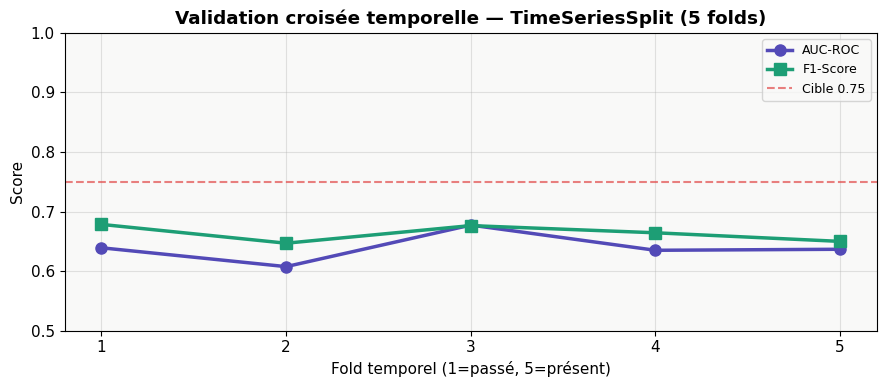

AUC moyen  : 0.639 ± 0.022
F1 moyen   : 0.663 ± 0.013
Stabilité  : ✅ STABLE


In [61]:
tscv = TimeSeriesSplit(n_splits=5)
X_all = df_ml[FEATURES].fillna(0)
y_all = df_ml[TARGET]

rf_cv = RandomForestClassifier(n_estimators=200, max_depth=8,
                                 class_weight='balanced', random_state=42)
scores_auc = cross_val_score(rf_cv, X_all, y_all, cv=tscv, scoring='roc_auc')
scores_f1  = cross_val_score(rf_cv, X_all, y_all, cv=tscv, scoring='f1')

fig, ax = plt.subplots(figsize=(9, 4))
folds = range(1, 6)
ax.plot(folds, scores_auc, color=COLORS['primary'],   marker='o', linewidth=2.5,
         markersize=8, label='AUC-ROC')
ax.plot(folds, scores_f1,  color=COLORS['secondary'], marker='s', linewidth=2.5,
         markersize=8, label='F1-Score')
ax.axhline(0.75, color=COLORS['danger'], linestyle='--', linewidth=1.5, alpha=0.7,
            label='Cible 0.75')
ax.set_xlabel('Fold temporel (1=passé, 5=présent)')
ax.set_ylabel('Score')
ax.set_title('Validation croisée temporelle — TimeSeriesSplit (5 folds)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.set_xticks(list(folds))
plt.tight_layout(); plt.show()

print(f'AUC moyen  : {scores_auc.mean():.3f} ± {scores_auc.std():.3f}')
print(f'F1 moyen   : {scores_f1.mean():.3f} ± {scores_f1.std():.3f}')
print(f'Stabilité  : {"✅ STABLE" if scores_auc.std() < 0.05 else "⚠️ VARIABLE — envisager retraining périodique"}')


### 🏢 ACTION MÉTIER — Gouvernance du ré-entraînement

**Règle de ré-entraînement à inscrire dans le runbook :**

```
┌─────────────────────────────────────────────────────────────────────┐
│  DÉCLENCHEURS DE RÉ-ENTRAÎNEMENT                                    │
│                                                                      │
│  Automatique (tous les 3 mois) — rythme standard                    │
│     ↓                                                                │
│  Anticipé si :                                                       │
│   - AUC du dernier fold TSCV descend sous 0.65                      │
│   - Taux de vrais positifs des ROUGE < 70% sur 1 mois              │
│   - Changement organisationnel majeur (nouvelle catégorie,          │
│     nouveaux agents, nouveau canal)                                  │
│                                                                      │
│  Différé si :                                                        │
│   - Période de forte variabilité (migration CRM en cours)           │
│   - Volumes atypiques (campagne marketing exceptionnelle)            │
└─────────────────────────────────────────────────────────────────────┘
```

**Ce que le concept drift signifie concrètement pour le support client :**
- **Drift de l'offre produit :** nouveau produit lancé → nouveau type de problèmes → ancien modèle aveugle
- **Drift de la clientèle :** expansion vers un nouveau pays → profils clients différents → seuils inadaptés
- **Drift des canaux :** si l'équipe ajoute WhatsApp → nouvelles dynamiques de conversation
- **Drift saisonnier :** certaines périodes (soldes, Black Friday) ont des patterns spécifiques

**Processus de ré-entraînement (checklist) :**
1. L'équipe data refait tourner le pipeline complet (NB1 → NB5) sur les données fraîches
2. Comparer les performances : nouveau modèle vs ancien sur le même test set
3. Si amélioration significative → déployer le nouveau modèle (procédure A/B testing sur 1 semaine idéalement)
4. Si dégradation → investiguer (bug de pipeline ? concept drift ? anomalie dans les données ?)
5. Archiver l'ancien modèle (pour rollback si besoin)
6. Documenter dans le runbook : date, version, performances, décision

**Question à poser à M. Kouame tous les trimestres :**
> *"Monsieur Kouame, est-ce que depuis notre dernière revue, il y a eu des changements majeurs*
> *dans votre organisation ? Nouveau produit, nouveau canal, nouvelle équipe, nouveau client majeur ?*
> *Ces éléments peuvent nécessiter un ajustement du modèle ML."*


---
## 📊 Partie 5 — Power BI : Architecture & DAX `[25 min]`

> 🎓 **Un dashboard n'est pas un rapport.**
> Un rapport affiche des chiffres. Un dashboard déclenche des décisions.
> La différence tient en une question : en 30 secondes, un superviseur sait-il quoi faire ?

### Architecture 5 pages

| Page | Question business | Public | Fréquence |
|---|---|---|---|
| 1 — Alertes & Risques | Quels tickets nécessitent une intervention aujourd'hui ? | Superviseur | Chaque matin |
| 2 — Performance SLA | Où et quand le SLA explose-t-il ? | Manager | Hebdo |
| 3 — Performance Agents | Qui performe ? Qui est surchargé ? | Manager | Hebdo |
| 4 — Tendances & Backlog | Quelle est la tendance globale ? | Direction | Mensuel |
| 5 — Satisfaction CSAT | Quel lien entre délai et satisfaction ? | Direction | Mensuel |

> 🎓 **La règle des 4-6 visuels par page.**
> Au-delà de 6 visuels, l'œil ne sait plus où regarder. Une page = une question business.

### Modèle en étoile

```
tickets_risque_scores  ──────┐
support_clean_analytics ─────┤──► FAITS → Pages 1-5
Calendrier (table DAX) ──────┘
```
Sources : `support_clean_analytics.csv` + `tickets_risque_scores.csv` + Table Calendrier DAX


### 🏢 ACTION MÉTIER — Le dashboard comme outil de conversation CODIR

Un bon dashboard ne raconte pas juste des chiffres — il **structure les réunions**.
Voici comment chaque page du dashboard AfriCare doit être utilisée dans les rituels de l'équipe :

**Page 1 — Alertes & Risques** (fréquence : **quotidienne**)
→ Rituel : stand-up matinal de 10 minutes
→ Superviseur projette la page, énumère les ROUGE, attribue les actions
→ Fin de stand-up : plan pour la journée basé sur les alertes

**Page 2 — Performance SLA** (fréquence : **hebdomadaire**)
→ Rituel : comité de direction support du lundi — 30 min
→ Revue des catégories en rouge de la semaine écoulée
→ Décision : adaptation du staffing, escalade vers les équipes produit/IT

**Page 3 — Performance Agents** (fréquence : **mensuelle**)
→ Rituel : entretiens mensuels one-on-one avec chaque agent
→ Le superviseur et l'agent regardent ensemble — conversation constructive
→ Objectif : identifier 1-2 axes d'amélioration personnalisés

**Page 4 — Tendances & Backlog** (fréquence : **mensuelle**)
→ Rituel : reporting mensuel à la direction
→ M. Kouame présente la page à son N+1 : volumes, tendances, actions prises
→ Décision : budget / recrutement / priorités du trimestre suivant

**Page 5 — Satisfaction CSAT** (fréquence : **trimestrielle**)
→ Rituel : revue stratégique CODIR
→ Argument pour les investissements : lien démontré entre opérationnel et satisfaction
→ Décision : orientations stratégiques (produits, organisation, outils)

**La règle d'or à imposer à l'équipe :**
Aucun chiffre discuté en réunion qui ne soit pas dans le dashboard.
Si un sujet nécessite des données qui ne sont pas dans le dashboard → c'est une demande d'évolution à planifier.
Cela force la cohérence et évite les débats sur des chiffres contradictoires.


### Mesures DAX essentielles

#### Table Calendrier (créer depuis Modélisation → Nouvelle table)

```dax
Calendrier =
ADDCOLUMNS(
    CALENDAR(MIN(tickets[created_at]), MAX(tickets[created_at])),
    "Annee",      YEAR([Date]),
    "Mois",       MONTH([Date]),
    "NomMois",    FORMAT([Date], "MMM YYYY"),
    "Semaine",    WEEKNUM([Date]),
    "JourSemaine",WEEKDAY([Date], 2),
    "EstWeekend", IF(WEEKDAY([Date],2)>=6, 1, 0)
)
```

#### Mesures KPIs

```dax
-- Taux SLA breach global
Taux SLA Breach % =
DIVIDE(
    CALCULATE(COUNTROWS(tickets), tickets[sla_breach] = 1),
    COUNTROWS(tickets),
    0
) * 100

-- CSAT moyen (exclure les nulls)
CSAT Moyen =
CALCULATE(
    AVERAGEX(tickets, tickets[csat]),
    NOT(ISBLANK(tickets[csat]))
)

-- Tickets en backlog actuellement
Tickets en Backlog =
CALCULATE(
    COUNTROWS(tickets),
    tickets[in_backlog] = 1
)

-- Score risque ML moyen
Score Risque Moyen =
AVERAGE(tickets_risque_scores[score_risque])

-- Tickets ROUGE (intervention immédiate)
Tickets ROUGE =
CALCULATE(
    COUNTROWS(tickets_risque_scores),
    SEARCH("ROUGE", tickets_risque_scores[niveau_alerte], 1, 0) > 0
)
```

#### Mesure pour le bandeau d'alerte conditionnel (Page 1)

```dax
-- Utilisée pour le formatage conditionnel : rouge si > 0, vert si = 0
Couleur Alerte =
IF(
    [Tickets ROUGE] > 0,
    "#E24B4A",   -- rouge
    "#1D9E75"    -- vert
)
```

> 🎓 **Le 'cry wolf effect' :**
> Un bandeau toujours rouge est ignoré après quelques jours.
> Un bandeau conditionnel (rouge seulement quand c'est urgent) reste remarqué et génère une action.

#### Mesure pour comparer avec la période précédente (LAG)

```dax
Breach Mois Précédent =
CALCULATE(
    [Taux SLA Breach %],
    DATEADD(Calendrier[Date], -1, MONTH)
)

Evolution Breach =
[Taux SLA Breach %] - [Breach Mois Précédent]
```


### Configuration Page 1 — Alertes & Risques

**Visuels recommandés (5 max) :**
1. **Carte** : `[Tickets ROUGE]` — fond rouge conditionnel si > 0
2. **Tableau** : `tickets_risque_scores` filtré ROUGE + ORANGE, trié par `score_risque` décroissant
3. **KPI Cards** (4) : Tickets ouverts | Score risque moyen | Nb ROUGE | Nb ORANGE
4. **Donut** : répartition des 4 niveaux ROUGE/ORANGE/JAUNE/VERT
5. **Barres horizontales** : score risque moyen par catégorie

**Source principale :** `tickets_risque_scores.csv` (généré par la Partie 4 ML)

---

### Check-list avant livraison

```
☐  Modèle en étoile créé (Relations → vérifier les jointures)
☐  Table Calendrier liée sur created_at (relation 1→N)
☐  Taux SLA breach = __ % (vérifier cohérence avec SQL Partie 3)
☐  Bandeau alerte Page 1 : rouge si Tickets ROUGE > 0
☐  Navigation entre pages (5 boutons)
☐  Slicers : Période | Canal | Pays | Agent
☐  tickets_risque_scores.csv chargé (source ML)
```


---

## ✅ Récapitulatif de la masterclass

### Ce qu'on a construit pour M. Kouame

| Partie | Livrable technique | Valeur métier |
|---|---|---|
| 1 — Audit | Rapport qualité + KPIs de référence | Vérité sur le taux breach réel (corrigé) |
| 2 — Nettoyage | `support_clean_analytics.csv` | Base unique de vérité pour toutes les analyses |
| 3 — SQL | 5 analyses + synthèse 4 insights | 4 recommandations chiffrées + plan 3 horizons |
| 4 — ML | `tickets_risque_scores.csv` (4 niveaux) | Priorisation quotidienne automatique |
| 5 — Power BI | Dashboard 5 pages + mesures DAX | Structuration des rituels de l'équipe |

### La transformation concrète pour l'équipe AfriCare

| Avant | Après |
|---|---|
| Parcourir 500+ tickets ouverts matinaux | 15 min de revue des tickets ROUGE prioritaires |
| SLA breach constaté après coup | Détection à la création → intervention préventive |
| Écart de performance agents invisible | Plan de mentorat 30 jours ciblé |
| CSAT perçu comme subjectif | Corrélation délai/CSAT prouvée → ROI staffing chiffré |
| Taux breach sous-estimé dans le CRM | Dashboard = source de vérité |
| Réunions sans base commune de chiffres | Rituels structurés autour des 5 pages |

### Les 3 conversations à avoir avec M. Kouame après la livraison

**Conversation 1 — À la livraison (J+0) :**
Présenter les 4 insights principaux. Faire valider les seuils ML (ROUGE/ORANGE/JAUNE/VERT).
Convenir du workflow quotidien superviseur.

**Conversation 2 — Après 1 mois (J+30) :**
Revue des taux de vrais positifs par niveau. Ajustement des seuils si nécessaire.
Recueil feedback des superviseurs. Plan pour les 2 mois suivants.

**Conversation 3 — Après 3 mois (J+90) :**
Mesure d'impact : baisse du taux de breach, amélioration CSAT, satisfaction équipe.
Premier ré-entraînement du modèle ML. Discussion sur les évolutions produit à venir.


---

**DataProjectLab** — apprendre la data sur des cas concrets, structurés et orientés métier.
